In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data/raw/raw.csv")
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [4]:
cat_columns = [ 'type_of_meal_plan','required_car_parking_space', 'room_type_reserved', 'market_segment_type',
       'repeated_guest','booking_status']
num_columns = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights','lead_time',
       'arrival_year', 'arrival_month', 'arrival_date','no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']

##### Encoding

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
label_encoder = LabelEncoder()
mappings = {}

for col in cat_columns:
    df[col] = label_encoder.fit_transform(df[col])

    mappings[col] = {label:code for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))}

In [7]:
mappings

{'type_of_meal_plan': {'Meal Plan 1': 0,
  'Meal Plan 2': 1,
  'Meal Plan 3': 2,
  'Not Selected': 3},
 'required_car_parking_space': {0: 0, 1: 1},
 'room_type_reserved': {'Room_Type 1': 0,
  'Room_Type 2': 1,
  'Room_Type 3': 2,
  'Room_Type 4': 3,
  'Room_Type 5': 4,
  'Room_Type 6': 5,
  'Room_Type 7': 6},
 'market_segment_type': {'Aviation': 0,
  'Complementary': 1,
  'Corporate': 2,
  'Offline': 3,
  'Online': 4},
 'repeated_guest': {0: 0, 1: 1},
 'booking_status': {'Canceled': 0, 'Not_Canceled': 1}}

In [8]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0,1
1,INN00002,2,0,2,3,3,0,0,5,2018,11,6,4,0,0,0,106.68,1,1
2,INN00003,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0,0
3,INN00004,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0,0
4,INN00005,2,0,1,1,3,0,0,48,2018,4,11,4,0,0,0,94.50,0,0


In [9]:
df = df.drop("Booking_ID", axis=1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(26000, 18)

##### Multicollineraity

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [13]:
X = add_constant(df)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

In [14]:
vif_data

,feature,VIF
0,const,4.129913e+07
1,no_of_adults,1.337855e+00
2,no_of_children,1.284896e+00
3,no_of_weekend_nights,1.077614e+00
4,no_of_week_nights,1.131223e+00
5,type_of_meal_plan,1.177405e+00
6,required_car_parking_space,1.032967e+00
7,room_type_reserved,1.555871e+00
8,lead_time,1.411162e+00
9,arrival_year,1.291251e+00


In [15]:
corr = df.corr()
corr

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
no_of_adults,1.000000,-0.049246,0.089085,0.110933,-0.010003,-0.002372,0.274697,0.154824,0.094557,0.009344,0.020377,0.306969,-0.240795,-0.063051,-0.146520,0.325352,0.156370,-0.093289
no_of_children,-0.049246,1.000000,0.010017,0.015904,-0.104764,0.020848,0.357778,0.012324,0.030721,0.004888,0.025196,0.096720,-0.049668,-0.021110,-0.029737,0.350109,0.096366,-0.063468
no_of_weekend_nights,0.089085,0.010017,1.000000,0.234186,-0.040495,-0.054212,0.028408,0.134318,0.027833,0.014321,0.005413,0.091357,-0.090030,-0.029229,-0.038840,-0.001932,0.013662,-0.071949
no_of_week_nights,0.110933,0.015904,0.234186,1.000000,-0.077211,-0.059488,0.083989,0.223333,0.015372,0.031120,-0.003860,0.116269,-0.119447,-0.034853,-0.057946,0.015449,0.030336,-0.126924
type_of_meal_plan,-0.010003,-0.104764,-0.040495,-0.077211,1.000000,-0.022719,-0.249130,-0.051198,0.095971,0.009994,-0.005947,0.180623,-0.071741,-0.011717,-0.045657,-0.104665,-0.010854,-0.035108
required_car_parking_space,-0.002372,0.020848,-0.054212,-0.059488,-0.022719,1.000000,0.017725,-0.040525,0.004269,-0.012479,-0.004620,-0.040252,0.107687,0.027046,0.058575,0.057458,0.071079,0.087028
room_type_reserved,0.274697,0.357778,0.028408,0.083989,-0.249130,0.017725,1.000000,-0.013204,0.086421,0.002498,0.029319,0.085663,-0.044617,-0.013340,-0.021578,0.489109,0.088528,-0.072900
lead_time,0.154824,0.012324,0.134318,0.223333,-0.051198,-0.040525,-0.013204,1.000000,0.171537,0.134461,0.036473,0.144750,-0.149185,-0.053972,-0.087298,-0.040446,-0.007849,-0.371473
arrival_year,0.094557,0.030721,0.027833,0.015372,0.095971,0.004269,0.086421,0.171537,1.000000,-0.323118,0.015807,0.108428,-0.008737,0.010835,0.024947,0.173449,-0.001262,-0.152222
arrival_month,0.009344,0.004888,0.014321,0.031120,0.009994,-0.012479,0.002498,0.134461,-0.323118,1.000000,-0.020236,-0.015608,-0.006239,-0.046451,-0.009762,0.067413,0.135426,0.012650


<Axes: >

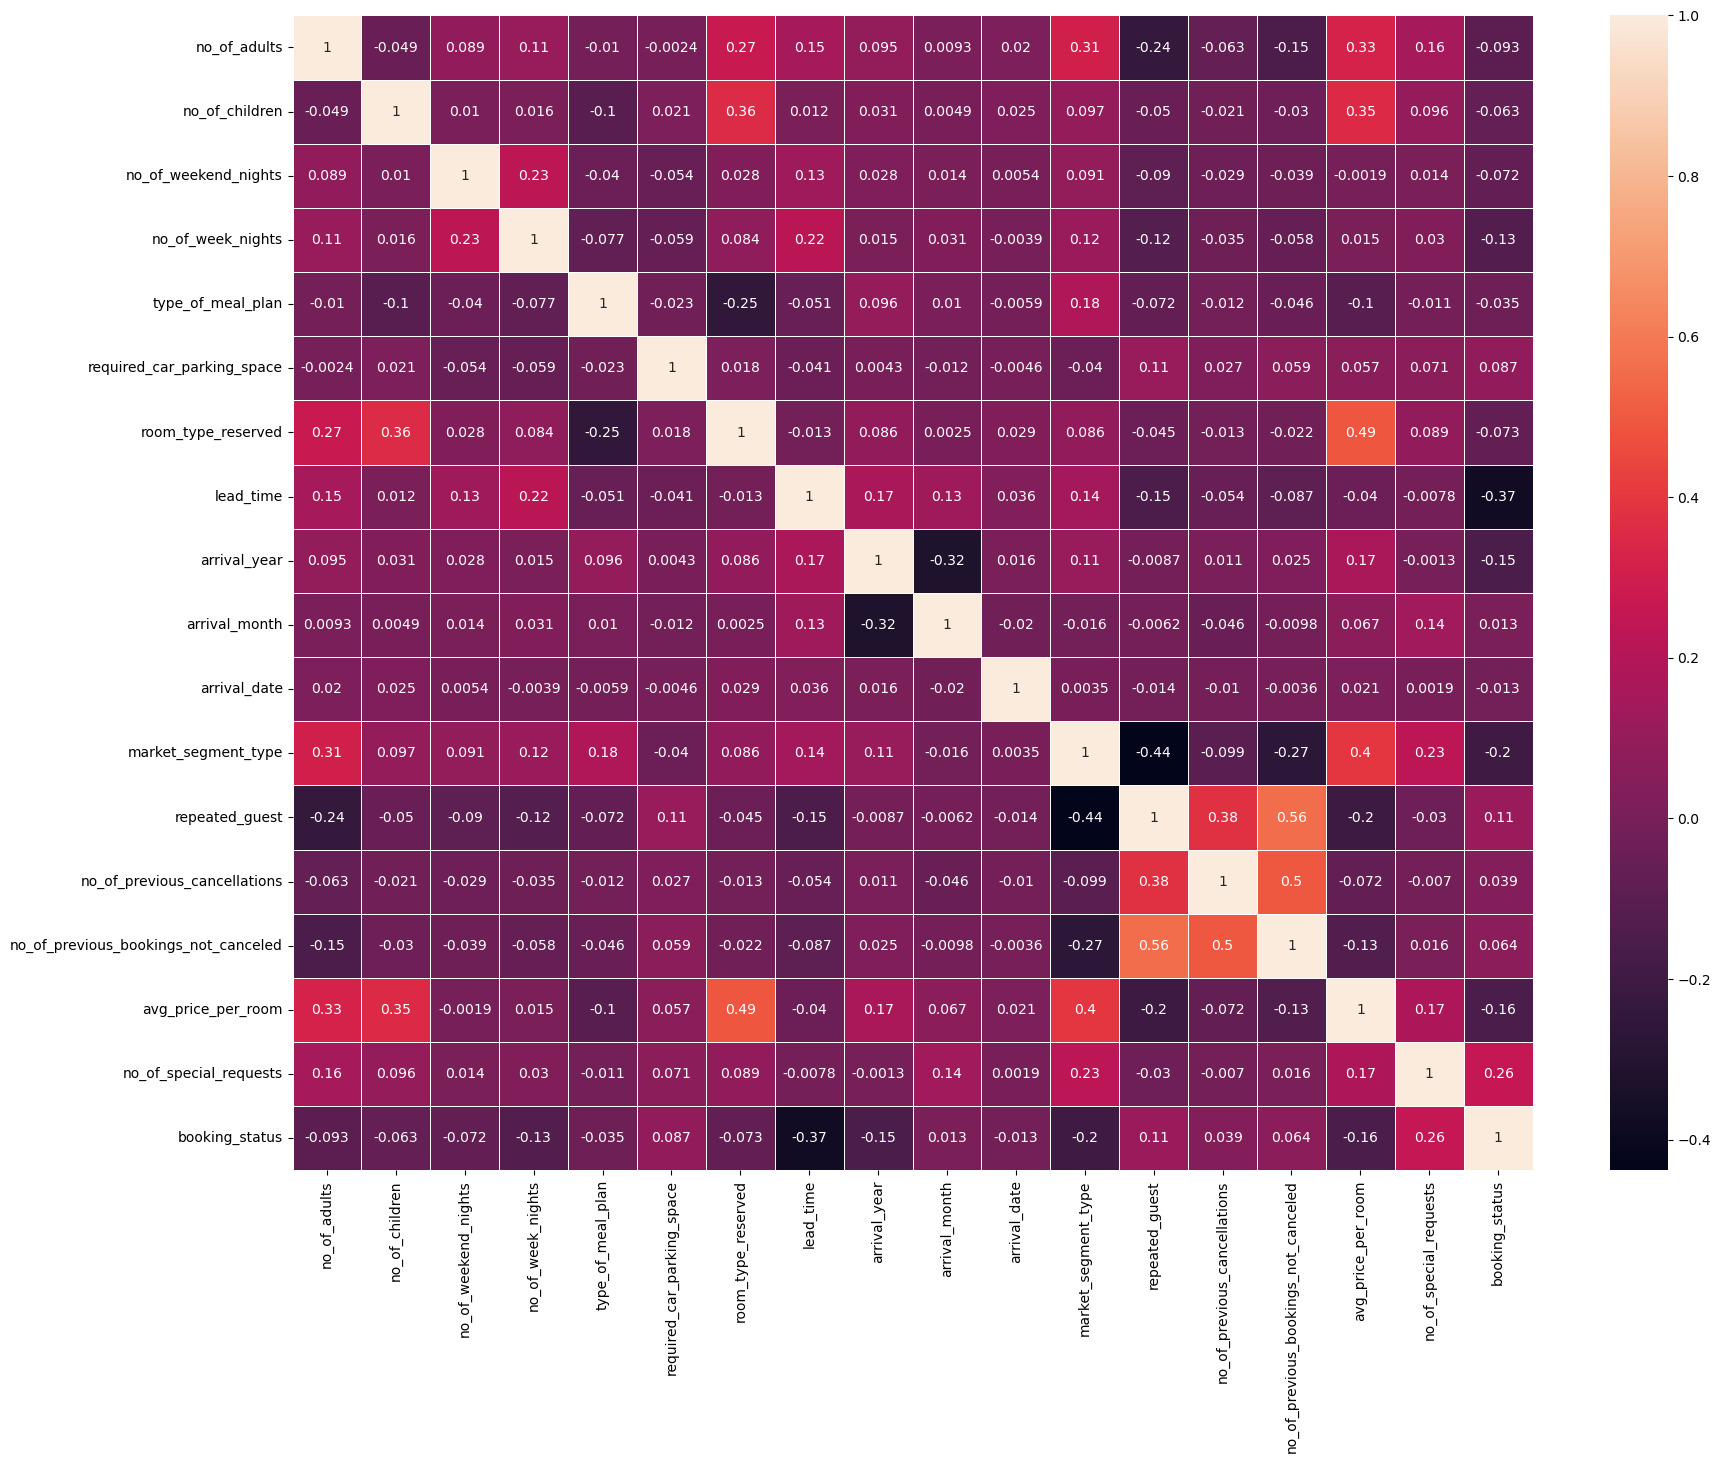

In [16]:
plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, linewidths=0.5)

##### Skewness

In [17]:
skewness = df.skew()
skewness

no_of_adults                            -0.297021
no_of_children                           4.005672
no_of_weekend_nights                     0.659718
no_of_week_nights                        1.601870
type_of_meal_plan                        1.638645
required_car_parking_space               4.559677
room_type_reserved                       1.373156
lead_time                                1.407857
arrival_year                            -1.963466
arrival_month                           -0.292238
arrival_date                             0.012177
market_segment_type                     -2.382309
repeated_guest                           5.249142
no_of_previous_cancellations            21.939192
no_of_previous_bookings_not_canceled    16.298982
avg_price_per_room                       0.588413
no_of_special_requests                   0.911121
booking_status                          -0.945939
dtype: float64

In [18]:
for col in df.columns:
    if skewness[col] > 5:
        df[col] = np.log1p(df[col])

##### Imbalanced Data

In [19]:
df["booking_status"].value_counts()

booking_status
1    18558
0     7442
Name: count, dtype: int64

In [20]:
X = df.drop(columns='booking_status')
y = df['booking_status']

In [21]:
X.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')

In [22]:
y.value_counts()

booking_status
1    18558
0     7442
Name: count, dtype: int64

In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

In [25]:
y_res

0        1
1        1
2        0
3        0
4        0
        ..
37111    0
37112    0
37113    0
37114    0
37115    0
Name: booking_status, Length: 37116, dtype: int32

In [26]:
y_res.value_counts( )

booking_status
1    18558
0    18558
Name: count, dtype: int64

In [27]:
balanced_df = pd.DataFrame(X_res, columns=X.columns)
balanced_df['booking_status'] = y_res

In [28]:
balanced_df 

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,0,0,0,224,2017,10,2,3,0.0,0.0,0.0,65.000000,0,1
1,2,0,2,3,3,0,0,5,2018,11,6,4,0.0,0.0,0.0,106.680000,1,1
2,1,0,2,1,0,0,0,1,2018,2,28,4,0.0,0.0,0.0,60.000000,0,0
3,2,0,0,2,0,0,0,211,2018,5,20,4,0.0,0.0,0.0,100.000000,0,0
4,2,0,1,1,3,0,0,48,2018,4,11,4,0.0,0.0,0.0,94.500000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37111,2,0,0,4,0,0,3,120,2018,9,20,4,0.0,0.0,0.0,143.100000,0,0
37112,2,0,0,4,0,0,3,120,2018,4,4,4,0.0,0.0,0.0,94.872627,0,0
37113,1,0,0,3,1,0,0,129,2018,5,5,4,0.0,0.0,0.0,101.216522,0,0
37114,1,0,1,0,2,0,0,4,2018,9,2,4,0.0,0.0,0.0,139.583629,0,0


In [29]:
if os.path.exists(r"data\raw\preprocessed_data.csv"):
    print("Preprocessed File already exists")
else:
    balanced_df.to_csv(r"data\raw\preprocessed_data.csv", index=False)

Preprocessed File already exists
